# Faster R-CNN Implementation Pipeline



- Preparing the Dataset for Faster R-CNN

- Removing Corrupted Annotations

- Splitting the Dataset into Training and Testing Sets

- Building the DataLoader

- Using a Pre-trained Backbone (ResNet-18)

- Defining the Anchor Generator and RPN

- Using ROI Align

- Building the Faster R-CNN Model

- Training the Model

- Calculating mAP

- Performing Prediction on Images

# Overall Implementation Pipeline

```text
Dataset
    │
    ▼
Annotation Validation
    │
    ▼
Removing Corrupted Data
    │
    ▼
Random Split
    │
    ▼
Train Loader
Test Loader
    │
    ▼
Backbone (ResNet-18)
    │
    ▼
RPN (Region Proposal Network)
    │
    ▼
ROI Align
    │
    ▼
Fast R-CNN Head
    │
    ▼
Training
    │
    ▼
Evaluation (mAP)
    │
    ▼
Prediction

In [1]:
import os
import cv2
import pandas as pd
import numpy as np
import torch
from torch.utils.data import DataLoader, random_split
import torchvision
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator, RPNHead
from torchvision.ops import RoIAlign, RoIPool, MultiScaleRoIAlign
import matplotlib.pyplot as plt

In [2]:
torch.cuda.is_available()

True

In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
DEVICE

device(type='cuda')

# Dataset Preparation

First, the images and their corresponding **Annotation** files are loaded.

The following steps are performed:

- Reading the image

- Reading the Annotation

- Extracting the Bounding Boxes

- Extracting the Labels

In [5]:
IMAGE_DIR = 'dataset/images'
ANNOTATIONS_DIR = 'dataset/annotations'
TARGET_SIZE = (224, 224)
BATCH_SIZE = 16

In [6]:
class_names = [d for d in os.listdir(IMAGE_DIR) if os.path.isdir(os.path.join(IMAGE_DIR, d))]

In [7]:
csv_files = [f for f in os.listdir(ANNOTATIONS_DIR) if f.endswith('.csv')]

In [8]:
label_map = {name: i + 1 for i, name in enumerate(class_names)}

In [9]:
label_map

{'airplane': 1, 'face': 2, 'motorcycle': 3}

# Checking Corrupted Annotations

One of the important steps during model training is **dataset quality validation**.

Some annotations may contain errors.

Assume that the **Bounding Box** coordinates are stored as:

```text
(x1, y1)
(x2, y2)
````

The condition for a valid Bounding Box is:

```text
x2 > x1
y2 > y1
```

Because:

```text
(x1,y1)
+-------------+
|             |
|             |
|             |
+-------------+
          (x2,y2)
```

If this condition is not satisfied, the **Bounding Box is considered invalid**.

```
```


In [10]:
dataset = []

for i in range(len(class_names)):
    class_name = class_names[i]
    class_dir = os.path.join(IMAGE_DIR, class_name)
    csv_file_name = csv_files[i]
    
    csv_path = os.path.join(ANNOTATIONS_DIR, csv_file_name)
    df_annotations = pd.read_csv(csv_path)

    for image_name in os.listdir(class_dir):
        image_path = os.path.join(class_dir, image_name)
        
        image = cv2.imread(image_path)
        h, w, _ = image.shape

        ann = df_annotations[df_annotations['image_name'] == image_name].iloc[0,1:].tolist()
        
        if ann[2] > ann[0] and ann[3] > ann[1]:
            ann[0] = int((ann[0] / w) * TARGET_SIZE[0])
            ann[1] = int((ann[1] / h) * TARGET_SIZE[0])
            ann[2] = int((ann[2] / w) * TARGET_SIZE[0])
            ann[3] = int((ann[3] / h) * TARGET_SIZE[0])
        
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image = cv2.resize(image, TARGET_SIZE)
            
            image_tensor = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1) / 255.0
            label_tensor = torch.tensor([label_map[class_name]], dtype=torch.int64)
            ann_tensor = torch.tensor([ann], dtype=torch.float32)
    
            target = {
                'boxes': ann_tensor,
                'labels': label_tensor
            }
            dataset.append((image_tensor, target))
        else:
            print(f"️Invalid box found and removed in '{image_path}': {ann}")
        
def collate_fn(batch):
    return tuple(zip(*batch))

️Invalid box found and removed in 'dataset/images/airplane/image_0118.jpg': [104, 38, 126, 38]


In [11]:
# dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)


# Dataset Splitting

After preparing the dataset, it should be divided into two parts:

- **Training Data (Train)**

- **Evaluation Data (Test)**

Assume that we have:

```text
2200 images
````

We want to use **90%** of the data for training and **10%** of the data for testing.

```
```


In [12]:
train_size = int(0.9 * len(dataset))
test_size = len(dataset) - train_size

In [13]:
generator = torch.Generator().manual_seed(42)

train_dataset, test_dataset = random_split(dataset, [train_size, test_size], generator=generator)

In [14]:
print(f"Dataset ({len(dataset)})")

Dataset (2032)


# Building the DataLoader

After splitting the dataset:

```text
Train Dataset
        │
        ▼
Train DataLoader

Test Dataset
        │
        ▼
Test DataLoader
````

The **DataLoader** is responsible for:

* Batch processing

* Shuffling the data

* Sending data to the GPU

```
```


In [15]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"Train ({len(train_dataset)}), Test ({len(test_dataset)})")

Train (1828), Test (204)



# Backbone Selection

In Faster R-CNN, the first step is extracting image features.

For this purpose, a CNN network called **Backbone** is used.

In this project, **ResNet18** is used.

Advantages:

- Lightweight
- Fast
- Low memory consumption

However, deeper models such as:

```text
ResNet50
ResNet101
````

usually achieve higher accuracy.

On the other hand:

* They require more memory.
* Training speed is slower.

```
 

In [16]:
resnet_model = torchvision.models.resnet18()
backbone = torch.nn.Sequential(*list(resnet_model.children())[:-2])
backbone.out_channels = 512

In [17]:
from torchsummary import summary
summary(backbone,(3,224,224))

Layer (type:depth-idx)                   Output Shape              Param #
├─Conv2d: 1-1                            [-1, 64, 112, 112]        9,408
├─BatchNorm2d: 1-2                       [-1, 64, 112, 112]        128
├─ReLU: 1-3                              [-1, 64, 112, 112]        --
├─MaxPool2d: 1-4                         [-1, 64, 56, 56]          --
├─Sequential: 1-5                        [-1, 64, 56, 56]          --
|    └─BasicBlock: 2-1                   [-1, 64, 56, 56]          --
|    |    └─Conv2d: 3-1                  [-1, 64, 56, 56]          36,864
|    |    └─BatchNorm2d: 3-2             [-1, 64, 56, 56]          128
|    |    └─ReLU: 3-3                    [-1, 64, 56, 56]          --
|    |    └─Conv2d: 3-4                  [-1, 64, 56, 56]          36,864
|    |    └─BatchNorm2d: 3-5             [-1, 64, 56, 56]          128
|    |    └─ReLU: 3-6                    [-1, 64, 56, 56]          --
|    └─BasicBlock: 2-2                   [-1, 64, 56, 56]          --
|

Layer (type:depth-idx)                   Output Shape              Param #
├─Conv2d: 1-1                            [-1, 64, 112, 112]        9,408
├─BatchNorm2d: 1-2                       [-1, 64, 112, 112]        128
├─ReLU: 1-3                              [-1, 64, 112, 112]        --
├─MaxPool2d: 1-4                         [-1, 64, 56, 56]          --
├─Sequential: 1-5                        [-1, 64, 56, 56]          --
|    └─BasicBlock: 2-1                   [-1, 64, 56, 56]          --
|    |    └─Conv2d: 3-1                  [-1, 64, 56, 56]          36,864
|    |    └─BatchNorm2d: 3-2             [-1, 64, 56, 56]          128
|    |    └─ReLU: 3-3                    [-1, 64, 56, 56]          --
|    |    └─Conv2d: 3-4                  [-1, 64, 56, 56]          36,864
|    |    └─BatchNorm2d: 3-5             [-1, 64, 56, 56]          128
|    |    └─ReLU: 3-6                    [-1, 64, 56, 56]          --
|    └─BasicBlock: 2-2                   [-1, 64, 56, 56]          --
|


# Freezing the Backbone

Since the Backbone is already pre-trained, it is usually **frozen**.

This means:

The weights of the Backbone are not updated during training.

```text
   Image
    │
    ▼
Backbone (Frozen)
    │
    ▼
Feature Map
````

In this case, only the newly added components of Faster R-CNN are trained.

Advantages:

* Faster training
* Requires less data
* Reduces the risk of Overfitting

```
```


In [18]:
for param in backbone.parameters():
    param.requires_grad = False

# Anchor Generator

After extracting the **Feature Map**, the **Anchor Boxes** need to be generated.

The **Anchor Generator** performs this task.

```text
  Feature Map
      │
      ▼
Anchor Generator
      │
      ▼
  Anchor Boxes
````

Then, these Anchor Boxes are passed to the **RPN**.

```
```


In [19]:
anchor_generator = AnchorGenerator(
    sizes=((32, 64, 128),),
    aspect_ratios=((0.5, 1.0, 2.0),)
)


# ROI Pool and ROI Align

In the early versions of Faster R-CNN, **ROI Pool** was used. However, ROI Pool had an important limitation.

## Problem with ROI Pool

Assume that a coordinate on the Feature Map is:

```text
6.8
````

Feature Map indices must be integers, so the coordinate is rounded:

```text
6.8 → Round → 7
```

This rounding operation causes spatial information loss and reduces localization accuracy.

# Solution: ROI Align

In **ROI Align**, rounding is removed. Instead, **Bilinear Interpolation** is used.

In this method:

* Decimal coordinates are preserved.
* Information from neighboring pixels is combined.


Instead of selecting only one pixel, a weighted average of neighboring pixels is calculated.

As a result:

* Information is preserved.
* Localization becomes more accurate.
* Model accuracy improves.

# Sampling Ratio

ROI Align has a parameter called:

```text
sampling_ratio
```

This parameter determines the number of sampling points used around each location.

For example:

```text
sampling_ratio = 2
```

means that sampling is performed in both X and Y directions.

# MultiScale ROI Align

The MultiScale version is used when multiple Feature Maps are available, such as:

```text
P2
P3
P4
P5
```

which are commonly used in **FPN (Feature Pyramid Network)**.

In this project, only one Feature Map is available, so the multi-scale functionality is not used and only the ROI Align mechanism is applied.

```




In [20]:
roi_pool = MultiScaleRoIAlign(
    featmap_names=['0'],
    output_size=7,
    sampling_ratio=2
)

# Defining the RPN Head

The **RPN Head** is responsible for generating two outputs for each **Anchor**:

- **Objectness Score**

- **Bounding Box Regression**

```text
Anchor
   │
   ▼
RPN Head
   │
   ├── Objectness Score
   └── Refined Bounding Box Coordinates
````

```
```


In [21]:
in_channels = backbone.out_channels
num_anchors = anchor_generator.num_anchors_per_location()[0]

rpn_head = RPNHead(in_channels=in_channels, num_anchors=num_anchors)

# Class Definition

In Faster R-CNN, **Label 0** is always reserved for the **Background** class.

Therefore, if we have three object classes:

```text
Airplane
Face
Motorcycle
````

The labels should be assigned as:

```text
Background → 0
Airplane → 1
Face → 2
Motorcycle → 3
```

For this reason, a **Label Map** is used to define the class-to-label mapping.




In [ ]:
NUM_CLASSES = len(class_names) + 1


# Building the Faster R-CNN Model

The model consists of the following components:

```text
- Backbone
- Anchor Generator
- RPN
- ROI Align
- Fast R-CNN Head
````

All of these components are defined during the model construction.

```


In [22]:

model = FasterRCNN(
    backbone,
    num_classes = NUM_CLASSES,
    rpn_anchor_generator = anchor_generator,
    rpn_head=rpn_head,
    box_roi_pool = roi_pool
)

# Two NMS Stages in Faster R-CNN

In Faster R-CNN, **Non-Maximum Suppression (NMS)** is applied twice.

## First Stage

After the RPN output:

```text
 Image
   │
   ▼
Backbone
   │
   ▼
  RPN
   │
  NMS
   │
Proposal
````

## Second Stage

After the final model output:

```text
  ROI Align
     │
     ▼
Fast R-CNN
     │
 Prediction
     │
    NMS
     │
 Final Boxes
```

Therefore:

* The first NMS removes duplicated proposals generated by the RPN.
* The second NMS refines the final predictions.

```
```


In [23]:
# optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.Adam(params, lr=0.001)

# Model Training

For training, the model is set to training mode:

```python
model.train()
````

In each batch, the following inputs are passed to the model:

```text
- Images
- Targets
```

The model returns a dictionary containing different loss values, such as:

```text
- loss_classifier
- loss_box_reg
- loss_objectness
- loss_rpn_box_reg
```

Then:

```python
sum(loss.values())
```

is calculated to obtain the final loss.

```
```


In [24]:
NUM_EPOCHS = 10

backbone.to(DEVICE)
model.to(DEVICE)
model.train()

for epoch in range(NUM_EPOCHS):
    epoch_losses = []
    print(f"Start Epoch {epoch+1}/{NUM_EPOCHS}")
    for i, (images, targets) in enumerate(train_loader):
        optimizer.zero_grad()
        
        images_gpu = [img.to(DEVICE) for img in images]
        targets_gpu = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]
            
        loss_dict = model(images_gpu, targets_gpu)
        losses = sum(loss_dict.values())
        

        
        if torch.isfinite(losses):
            epoch_losses.append(losses.item())
            losses.backward()
            optimizer.step()
            
    if epoch_losses:
        mean_loss = sum(epoch_losses) / len(epoch_losses)
        print(f"Epoch {epoch+1} | Loss: {mean_loss:.4f}")
    else:
        print(f"Epoch {epoch+1} | No valid losses")

Start Epoch 1/10
Epoch 1 | Loss: 2.4084
Start Epoch 2/10
Epoch 2 | Loss: 0.8523
Start Epoch 3/10
Epoch 3 | Loss: 0.7861
Start Epoch 4/10
Epoch 4 | Loss: 0.7494
Start Epoch 5/10
Epoch 5 | Loss: 0.7205
Start Epoch 6/10
Epoch 6 | Loss: 0.7070
Start Epoch 7/10
Epoch 7 | Loss: 0.6827
Start Epoch 8/10
Epoch 8 | Loss: 0.6752
Start Epoch 9/10
Epoch 9 | Loss: 0.6663
Start Epoch 10/10
Epoch 10 | Loss: 0.6549


# mAP Calculation

To evaluate the model performance, the **mAP (Mean Average Precision)** metric is used.

The calculation process:

```text
Test Images
      │
      ▼
Prediction
      │
      ▼
TorchMetrics
      │
      ▼
     mAP
````

In the evaluation function:

* The model is set to `eval()` mode.
* Gradient computation is disabled.
* Test images are passed to the model.
* The model outputs are compared with the ground-truth labels, and the mAP value is calculated.

In this project, the obtained mAP on the test data is approximately **41%**. In other runs, values around **50%** have also been observed. This variation occurs due to the stochastic nature of training, random seed, dataset split, and the number of training epochs.

```
```


In [25]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision

In [26]:
def calculate_map(model_to_eval, data_loader, device):
    metric = MeanAveragePrecision(box_format='xyxy')
    model_to_eval.eval()
    
    with torch.no_grad():
        for images, targets in data_loader:
            images_gpu = [img.to(device) for img in images]
            targets_gpu = [{k: v.to(device) for k, v in t.items()} for t in targets]
            
            predictions = model_to_eval(images_gpu)
            metric.update(predictions, targets_gpu)

    return metric.compute()

In [27]:
# Train Set mAP
train_map_results = calculate_map(model, train_loader, device=DEVICE)

In [28]:
print(train_map_results['map'])

tensor(0.4631)


In [29]:
# Test Set mAP
test_map_results = calculate_map(model, test_loader, device=DEVICE)

In [30]:
print(test_map_results['map'])

tensor(0.4567)


# Prediction

During the prediction phase:

1. The image is passed to the model.
    
2. The model generates **Bounding Boxes**, **Labels**, and **Scores**.

3. Only predictions with a score higher than the defined **Threshold** are displayed.

For example, if:

```text
Threshold = 0.7
````

only predictions with more than **70% confidence** will be drawn.

```
```


In [31]:
def visualize_result(image_path, model, label_map, threshold=0.6):
    model.eval()
    
    img_bgr = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    image_rgb_resized = cv2.resize(img_rgb, TARGET_SIZE)
    img_tensor = (torch.tensor(image_rgb_resized, dtype=torch.float32).permute(2, 0, 1) / 255.0).to(DEVICE)
    
    with torch.no_grad():
        prediction = model([img_tensor])

    class_names_viz = {v: k for k, v in label_map.items()}
    class_names_viz[0] = '__background__'
    

    img_to_draw = img_rgb.copy()
    original_h, original_w, _ = img_to_draw.shape
    model_h, model_w = TARGET_SIZE

    w_ratio = original_w / model_w
    h_ratio = original_h / model_h
    
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 0.5
    font_thickness = 1
    
    for box, label, score in zip(prediction[0]['boxes'], prediction[0]['labels'], prediction[0]['scores']):
        if score > threshold:
            x1, y1, x2, y2 = box.cpu().numpy()
            x1, x2 = int(x1 * w_ratio), int(x2 * w_ratio)
            y1, y2 = int(y1 * h_ratio), int(y2 * h_ratio)
            
            class_name = class_names_viz[label.item()]
            text = f"{class_name}: {score:.2f}"
            color_rgb = (0, 255, 0)
            
            cv2.rectangle(img_to_draw, (x1, y1), (x2, y2), color_rgb, 2)
            (text_width, text_height), baseline = cv2.getTextSize(text, font, font_scale, font_thickness)
            cv2.rectangle(img_to_draw, (x1, y1 - text_height - baseline), (x1 + text_width, y1), color_rgb, -1)
            cv2.putText(img_to_draw, text, (x1, y1 - baseline), font, font_scale, (0, 0, 0), font_thickness)

    plt.figure(figsize=(10, 10))
    plt.imshow(img_to_draw)
    plt.axis('off')
    plt.show()

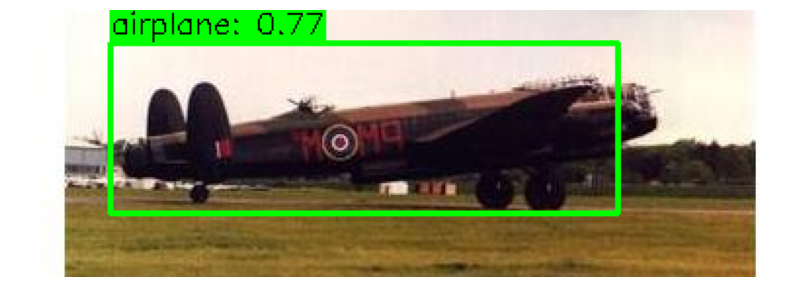

In [32]:
TEST_IMAGE_PATH = 'dataset/images/airplane/image_0010.jpg'
visualize_result(TEST_IMAGE_PATH, model, label_map=label_map, threshold=0.7)

# Reasons for Low Model Accuracy

Several factors have affected the final performance of the model:

- Limited number of training images (around 2200 samples)
- Training for only 10 Epochs
- Using a lightweight Backbone (**ResNet18**)
- Using default parameters without optimization
- Lack of detailed Hyperparameter tuning

---

# Suggestions for Performance Improvement

To improve the model accuracy, the following approaches can be applied:

- Increasing the number of Epochs (e.g., 50 or 100)
- Using stronger Backbones such as **ResNet50** or **ResNet101**
- Increasing the amount of training data
- Applying Data Augmentation
- Tuning RPN and NMS parameters
- Adjusting Anchor sizes based on the object dimensions in the dataset
- Selecting suitable Threshold values for Prediction
- Using **Feature Pyramid Network (FPN)**

---

# Summary

In this section, a complete implementation of **Faster R-CNN** using the built-in capabilities of **PyTorch** was performed. All steps were covered, including dataset preparation and validation, data splitting, DataLoader creation, Backbone selection, Anchor Generator definition, RPN, ROI Align, and model training. Additionally, the calculation of the **mAP** metric and performing prediction on images were explained.

Finally, it was shown that model performance depends not only on the architecture but also on factors such as **dataset quality, number of training samples, Backbone selection, number of Epochs, and proper Hyperparameter tuning**. Therefore, achieving better results requires experimentally adjusting and evaluating these factors.
```
